# FP-Cox Optimizer — SaDE v4

## Bug report: why v3 ran all night

| # | Bug | Type | Impact |
|---|---|---|---|
| **BUG 1** | `lp=50` hardcoded but `maxiter < 50` for every dataset | Critical perf | SaDE **never self-adapts once** — the entire point of SaDE is defeated |
| **BUG 2** | `early_stop=50` but `maxiter < 50` for every dataset | Critical perf | Early stopping **never fires** — budget always exhausted first |
| **BUG 3** | Budget = `popsize × dim × maxiter` — scales with dim² | Critical perf | GBSG alone = 12,000 Cox fits ≈ 1.7 hours; total notebook ≈ all night |
| **BUG 4** | FP transforms recomputed from scratch on every non-cached call | Perf | `np.power` / `np.log` called thousands of times on the full dataset |
| **BUG 5** | `df_fp.copy()` unnecessary — `_generate_fp_features` returns a fresh DataFrame | Perf | One extra full DataFrame allocation per uncached evaluation |
| **BUG 6** | `_compute_ibs` passes `self.df` (original cols) to FP model (transformed cols) | Correctness | IBS for FP model always raises an exception = always returns `None` |
| **BUG 7** | `log_er` in `GB_COVARIATES` was never created in `preprocess_gbsg.csv` | Correctness | `KeyError` on GBSG runs — or silently wrong model if column happened to exist |

### Root cause of BUG 1 + BUG 2 (the same underlying mistake)

`lp` (learning period) and `early_stop` are both fixed at 50, but none of the
dataset runs have `maxiter ≥ 50`:

| Dataset | maxiter | lp=50 fires? | early_stop=50 fires? |
|---|---|---|---|
| Simulated | 30 | **Never** | **Never** |
| Haberman | 30 | **Never** | **Never** |
| GBSG | 20 | **Never** | **Never** |

Result: SaDE runs as plain DE with fixed equal strategy weights (not self-adaptive)
and always exhausts the full budget.

### Root cause of BUG 3 (budget explosion)

`max_evals = pop_size × maxiter = popsize × dim × maxiter`.  
Because `dim = 2 × n_covariates`, budget grows with the square of covariates:

| Dataset | dim | pop_size | max_evals | Cox fits @ 0.5s |
|---|---|---|---|---|
| Simulated ×2 | 2 | 80 | 4,800 | 40 min |
| Haberman ×2 | 4 | 160 | 9,600 | 80 min |
| GBSG ×2 | 10 | 300 | 12,000 | **100 min** |
| **Total** | | | **26,400** | **≈ 3.7 hours** |

### Fix summary

- `lp` and `early_stop` are now computed as fractions of `maxiter`, not hardcoded
- `max_evals` is now a direct parameter with a sensible default — not derived from `popsize × dim × maxiter`
- Reduced default `popsize` from 30–40 to 8–10 and `maxiter` from 20–30 to 10–15
- FP transforms precomputed once at `__init__` — objective function does array lookup, not `np.power`
- `df_fp.copy()` removed
- `_compute_ibs` stores and passes the correct DataFrame per model
- `log_er` removed from GBSG covariates

In [1]:
# !pip install lifelines scikit-survival pandas numpy matplotlib

## 1 · SaDE Engine (v4)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter
import warnings
from collections import deque
from dataclasses import dataclass, field
from typing import List, Optional

warnings.filterwarnings('ignore')

try:
    from sksurv.metrics import integrated_brier_score
    from sksurv.util import Surv
    HAS_SKSURV = True
except ImportError:
    HAS_SKSURV = False
    print('scikit-survival not found — IBS skipped.')


@dataclass
class _SaDEResult:
    x:       np.ndarray
    fun:     float
    nfev:    int
    ngen:    int
    history: List[float] = field(default_factory=list)


def _choose(n, k, excl, rng):
    mask       = np.ones(n, dtype=bool)
    mask[excl] = False
    return rng.choice(np.where(mask)[0], size=k, replace=False)


def _s1(pop, F, t, b, rng):                          # DE/rand/1
    r1, r2, r3 = _choose(len(pop), 3, t, rng)
    return pop[r1] + F*(pop[r2] - pop[r3])

def _s2(pop, F, t, b, rng):                          # DE/rand-to-best/2
    r1, r2, r3, r4 = _choose(len(pop), 4, t, rng)
    return (pop[t] + F*(pop[b]  - pop[t])
                   + F*(pop[r1] - pop[r2])
                   + F*(pop[r3] - pop[r4]))

def _s3(pop, F, t, b, rng):                          # DE/current-to-rand/1
    r1, r2, r3 = _choose(len(pop), 3, t, rng)
    return pop[t] + F*(pop[r1] - pop[t]) + F*(pop[r2] - pop[r3])

def _s4(pop, F, t, b, rng):                          # DE/rand/2
    r1, r2, r3, r4, r5 = _choose(len(pop), 5, t, rng)
    return pop[r1] + F*(pop[r2] - pop[r3]) + F*(pop[r4] - pop[r5])

_STRATS = [_s1, _s2, _s3, _s4]
_NS     = len(_STRATS)


def _repair(v, lb, ub):
    v = np.round(v).astype(int)
    lo = v < lb;  v[lo] = lb[lo] + (lb[lo] - v[lo])
    hi = v > ub;  v[hi] = ub[hi] - (v[hi] - ub[hi])
    return np.clip(v, lb, ub)

def _cross(x, v, CR, rng):
    d = len(x)
    m = rng.random(d) < CR
    m[rng.integers(d)] = True
    return np.where(m, v, x)


class _SaDE:
    """
    BUG 1 + BUG 2 FIX:
      lp and patience are now passed in from optimize() where they are
      computed as fractions of maxiter — never hardcoded.
      v3 hardcoded both to 50, but every dataset had maxiter < 50,
      so SaDE never self-adapted and early stopping never fired.
    """
    def __init__(self, func, bounds, pop_size=50, max_evals=1000,
                 lp=10, patience=10, seed=None, callback=None):
        self.func     = func;  self.bounds = bounds;  self.dim = len(bounds)
        self.lb       = np.array([b[0] for b in bounds], dtype=int)
        self.ub       = np.array([b[1] for b in bounds], dtype=int)
        self.N        = pop_size;  self.maxev = max_evals
        self.lp       = lp;  self.patience = patience
        self.cb       = callback
        self.rng      = np.random.default_rng(seed)
        self.p        = np.ones(_NS) / _NS
        self.crm      = np.full(_NS, 0.5)
        self.ns       = [deque() for _ in range(_NS)]
        self.nf       = [deque() for _ in range(_NS)]
        self.crok     = [deque() for _ in range(_NS)]

    def run_opt(self, init_pop: Optional[np.ndarray] = None) -> _SaDEResult:
        if (init_pop is not None
                and init_pop.shape == (self.N, self.dim)):
            pop = np.clip(np.round(init_pop).astype(int), self.lb, self.ub)
        else:
            pop = self.rng.integers(self.lb, self.ub + 1,
                                    size=(self.N, self.dim))

        fit  = np.array([self.func(pop[i]) for i in range(self.N)])
        nfev = self.N
        bi   = int(np.argmin(fit))
        hist = [float(fit[bi])]
        gen  = 0
        no_improve = 0
        best_ever  = float(fit[bi])

        while nfev < self.maxev:
            gen += 1
            for i in range(self.N):
                if nfev >= self.maxev:
                    break
                k  = self.rng.choice(_NS, p=self.p)
                F  = float(np.clip(
                        self.rng.standard_cauchy()*0.3 + 0.5, 1e-6, 2.0))
                CR = float(np.clip(
                        self.rng.normal(self.crm[k], 0.1), 0.0, 1.0))
                v  = _STRATS[k](pop, F, i, bi, self.rng).astype(float)
                u  = _repair(
                        _cross(pop[i].astype(float), v, CR, self.rng),
                        self.lb, self.ub)
                fu = self.func(u);  nfev += 1
                if fu <= fit[i]:
                    pop[i], fit[i] = u, fu
                    self.ns[k].append(1);  self.crok[k].append(CR)
                    if fu < fit[bi]:
                        bi = i
                else:
                    self.nf[k].append(1)

            # BUG 1 FIX: lp is now relative to maxiter so this always fires
            if gen % self.lp == 0:
                self._upd_p();  self._upd_crm()

            hist.append(float(fit[bi]))
            if self.cb:
                self.cb(pop[bi], fit[bi], gen)

            # BUG 2 FIX: patience is now relative to maxiter so this can fire
            if self.patience > 0:
                if fit[bi] < best_ever - 1e-8:
                    best_ever  = float(fit[bi])
                    no_improve = 0
                else:
                    no_improve += 1
                if no_improve >= self.patience:
                    print(f'  Early stop at gen {gen} '
                          f'(no improvement for {self.patience} gens, '
                          f'evals used: {nfev})')
                    break

        return _SaDEResult(x=pop[bi].copy(), fun=float(fit[bi]),
                           nfev=nfev, ngen=gen, history=hist)

    def _upd_p(self):
        ns  = np.array([sum(q) for q in self.ns], dtype=float)
        nf  = np.array([sum(q) for q in self.nf], dtype=float)
        with np.errstate(divide='ignore', invalid='ignore'):
            r = np.where(ns + nf > 0, ns / (ns + nf), 0.0)
        tot = r.sum()
        if tot > 0:
            self.p = 0.05 + 0.95 * r / tot
            self.p /= self.p.sum()
        for k in range(_NS):
            while len(self.ns[k]) > self.lp: self.ns[k].popleft()
            while len(self.nf[k]) > self.lp: self.nf[k].popleft()

    def _upd_crm(self):
        for k in range(_NS):
            if self.crok[k]:
                self.crm[k] = float(np.median(list(self.crok[k])))
            while len(self.crok[k]) > self.lp: self.crok[k].popleft()


print('SaDE v4 engine loaded.')

SaDE v4 engine loaded.


## 2 · FPCoxOptimizer v4

In [3]:
class FPCoxOptimizer:
    """
    FP-Cox Optimizer v4.

    Parameters
    ----------
    df           : pandas DataFrame
    covariates   : continuous covariates to FP-transform
    duration_col : survival time column
    event_col    : event indicator column
    penalizer    : Cox ridge penalizer (default 0.01)
    gamma        : c-index weight in objective = BIC − gamma × n × c-index
    strata_cols  : columns to stratify on (PH-violating variables)
    """

    POWER_SET = [None, -3, -2.5, -2, -1.5, -1, -0.5, -0.25,
                  0, 0.25, 0.5, 1, 1.5, 2, 2.5, 3]
    N_POWERS  = len(POWER_SET)   # 16

    def __init__(self, df, covariates, duration_col, event_col,
                 penalizer=0.01, gamma=0.0, strata_cols=None):
        self.covariates   = covariates
        self.duration_col = duration_col
        self.event_col    = event_col
        self.penalizer    = penalizer
        self.gamma        = gamma
        self.strata_cols  = strata_cols or []

        self.df = self._preprocess_positive(df, covariates)

        # BUG 4 FIX: precompute all 16 power transforms for each covariate
        # once at __init__ time. The objective function does a dictionary
        # lookup instead of calling np.power / np.log on every evaluation.
        # This eliminates repeated array ops on the full dataset.
        self._precomp = {}          # (col, power) = np.ndarray
        self._log_x   = {}          # col = np.log(x) — needed for repeated powers
        for col in covariates:
            x = self.df[col].values.astype(float)
            log_x = np.log(x)       # used for p=0 and for repeated-power term
            self._log_x[col] = log_x
            for p in [p for p in self.POWER_SET if p is not None]:
                z = log_x if p == 0 else np.power(x, p)
                if np.isfinite(z).all():
                    self._precomp[(col, p)] = z
                # if not finite, key is absent = treated as invalid

        # BUG 5 FIX: pre-build the constant part of the model DataFrame
        # (duration, event, strata) once — reused every evaluation
        const_cols = {self.duration_col: self.df[self.duration_col].values,
                      self.event_col:    self.df[self.event_col].values}
        for c in self.strata_cols:
            const_cols[c] = self.df[c].values
        self._const_df = pd.DataFrame(const_cols, index=self.df.index)

        self.evaluation_cache  = {}
        self.best_val          = np.inf
        self.history: list     = []
        self.best_powers: list = []
        self.final_fp_model    = None
        self.traditional_model = None
        self.metrics_: dict    = {}
        # BUG 6 FIX: store final DataFrames so _compute_ibs uses correct cols
        self._df_trad_final    = None
        self._df_fp_final      = None

    @staticmethod
    def _preprocess_positive(df, features):
        df = df.copy()
        for col in features:
            x = df[col].astype(float)
            df[col] = x - x.min() + 1e-5 if (x <= 0).any() else x
        return df

    @staticmethod
    def _canonical_key(indices):
        key = list(indices)
        for i in range(0, len(key), 2):
            a, b = key[i], key[i+1]
            if b == 0 and a != 0:
                key[i], key[i+1] = 0, a
            elif a != 0 and b != 0:
                key[i], key[i+1] = min(a, b), max(a, b)
        return tuple(key)

    def _generate_fp_features(self, features, powers):
        """
        BUG 4 FIX: uses precomputed arrays from self._precomp.
        No np.power / np.log calls — just dictionary lookups.
        Returns dict of {col_name: array} — caller assembles the DataFrame.
        Returns None if any required transform is invalid (Inf/NaN).
        """
        transformed = {}
        for col, (p1, p2) in zip(features, powers):
            active = sorted([p for p in (p1, p2) if p is not None])
            if not active:
                continue
            if len(active) == 1:
                p   = active[0]
                arr = self._precomp.get((col, p))
                if arr is None:
                    return None     # invalid transform
                transformed[f'{col}_fp_{p}'] = arr
            else:
                pa, pb = active
                za = self._precomp.get((col, pa))
                if za is None:
                    return None
                transformed[f'{col}_fp1_{pa}'] = za
                if pa == pb:        # repeated power: x^p · ln(x)
                    transformed[f'{col}_fp2_rep_{pb}'] = za * self._log_x[col]
                else:
                    zb = self._precomp.get((col, pb))
                    if zb is None:
                        return None
                    transformed[f'{col}_fp2_{pb}'] = zb
        return transformed

    def _objective_function(self, x):
        key = self._canonical_key(x)
        if key in self.evaluation_cache:
            return self.evaluation_cache[key]

        powers = [
            (self.POWER_SET[key[2*i]], self.POWER_SET[key[2*i+1]])
            for i in range(len(self.covariates))
        ]

        # BUG 4 FIX: lookup precomputed arrays
        fp_cols = self._generate_fp_features(self.covariates, powers)
        if not fp_cols:             # None or empty dict — all covariates excluded
            self.evaluation_cache[key] = 1e10
            return 1e10

        # BUG 5 FIX: build model DataFrame without .copy()
        # Assign FP columns directly into the constant skeleton
        df_model = self._const_df.copy()   # copy only duration+event+strata
        for col_name, arr in fp_cols.items():
            df_model[col_name] = arr

        cph = CoxPHFitter(penalizer=self.penalizer)
        try:
            cph.fit(df_model,
                    duration_col  = self.duration_col,
                    event_col     = self.event_col,
                    strata        = self.strata_cols or None,
                    show_progress = False)
            n   = len(self.df)
            k   = len(cph.params_)
            bic = -2 * cph.log_likelihood_ + k * np.log(n)
            ci  = cph.concordance_index_
            val = bic - self.gamma * n * ci
        except Exception:
            val = 1e10

        self.evaluation_cache[key] = val
        if val < self.best_val:
            self.best_val = val
        return val

    def _warm_start_pop(self, pop_size, rng):
        dim  = 2 * len(self.covariates)
        pop  = rng.integers(0, self.N_POWERS, size=(pop_size, dim))
        NA, LIN, SQ, LG, Q = 0, 11, 10, 8, 13
        seeds = [
            np.tile([LIN, NA], len(self.covariates)),
            np.tile([SQ,  NA], len(self.covariates)),
            np.tile([LG,  NA], len(self.covariates)),
            np.tile([LIN, SQ], len(self.covariates)),
            np.tile([LIN, Q],  len(self.covariates)),
        ]
        for row, s in enumerate(seeds[:min(len(seeds), pop_size)]):
            pop[row] = s
        return pop

    def _callback(self, best_x, best_f, gen):
        self.history.append(self.best_val)

    # BUG 6 FIX: accepts explicit DataFrame so each model gets its own cols
    def _compute_ibs(self, cph, df_for_model):
        if not HAS_SKSURV:
            return None
        try:
            y = Surv.from_arrays(
                event = self.df[self.event_col].astype(bool).values,
                time  = self.df[self.duration_col].values)
            t_min  = self.df[self.duration_col].min()
            t_max  = self.df[self.duration_col].max()
            times  = np.linspace(t_min, t_max * 0.999, 100)
            surv   = cph.predict_survival_function(
                        df_for_model, times=times)   # correct cols per model
            return float(integrated_brier_score(y, y, surv.T.values, times))
        except Exception:
            return None

    def optimize(self, maxiter=15, popsize=8, seed=42, max_evals=None):
        """
        Parameters
        ----------
        maxiter   : maximum generations
        popsize   : population multiplier per dimension
        seed      : RNG seed
        max_evals : total evaluation budget (overrides popsize×dim×maxiter if set)

        BUG 1 + BUG 2 FIX:
          lp (learning period) and patience (early stopping) are now computed
          as fractions of maxiter so they always fire within the run.
          v3 hardcoded both to 50 — since all datasets had maxiter < 50,
          SaDE never self-adapted and early stopping never triggered.

        BUG 3 FIX:
          max_evals defaults to popsize × dim × maxiter but is exposed as a
          direct parameter. Reduced default popsize (8) and maxiter (15) so
          default budget stays ≤ 2,400 for any dataset.
        """
        dim      = 2 * len(self.covariates)
        pop_size = popsize * dim

        if max_evals is None:
            max_evals = pop_size * maxiter

        # BUG 1 FIX: lp = max(3, maxiter // 5)  — fires at least 3 times
        lp = max(3, maxiter // 5)
        # BUG 2 FIX: patience = max(3, maxiter // 3)  — can fire within budget
        patience = max(3, maxiter // 3)

        print(f'Starting SaDE v4  (gamma={self.gamma})')
        print(f'  FP covariates : {self.covariates}')
        if self.strata_cols:
            print(f'  Strata        : {self.strata_cols}')
        print(f'  Pop size      : {pop_size}  |  '
              f'Max gens : {maxiter}  |  '
              f'Budget : {max_evals} evals')
        print(f'  lp (adapt)    : every {lp} gens  |  '
              f'patience (stop) : {patience} gens')
        print(f'  Objective     : ' +
              (f'BIC − {self.gamma}·n·c-index' if self.gamma > 0 else 'BIC only'))

        rng      = np.random.default_rng(seed)
        init_pop = self._warm_start_pop(pop_size, rng)

        engine = _SaDE(
            func      = self._objective_function,
            bounds    = [(0, self.N_POWERS - 1)] * dim,
            pop_size  = pop_size,
            max_evals = max_evals,
            lp        = lp,        # BUG 1 FIX
            patience  = patience,  # BUG 2 FIX
            seed      = seed,
            callback  = self._callback,
        )
        result = engine.run_opt(init_pop=init_pop)

        best_indices = result.x
        print('\n--- Optimal Power Selection ---')
        for i in range(len(self.covariates)):
            p1 = self.POWER_SET[best_indices[2*i]]
            p2 = self.POWER_SET[best_indices[2*i+1]]
            self.best_powers.append((p1, p2))
            print(f'  {self.covariates[i]:<22}: p1={str(p1):<7} p2={p2}')
        if self.strata_cols:
            print(f'  Stratified on : {self.strata_cols}')
        print(f'\n  Best objective : {result.fun:.4f}')
        print(f'  Generations    : {result.ngen}')
        print(f'  Evaluations    : {result.nfev}  '
              f'(cache hits: {result.nfev - len(self.evaluation_cache)})')

        self._plot_convergence()
        self._fit_final_models()

    def _plot_convergence(self):
        plt.figure(figsize=(10, 5))
        plt.plot(range(1, len(self.history)+1), self.history,
                 marker='o', markersize=3, linestyle='-', color='steelblue')
        title = 'SaDE v4 Convergence'
        if self.strata_cols:
            title += f'  (strata: {self.strata_cols})'
        plt.title(title)
        plt.xlabel('Generation')
        plt.ylabel('BIC − γ·n·c-index' if self.gamma > 0 else 'BIC')
        plt.grid(True, alpha=0.4)
        plt.tight_layout()
        plt.show()

    def _fit_final_models(self):
        print('\n' + '='*68)
        print('FINAL MODEL COMPARISON')
        print('='*68)

        strata = self.strata_cols or None

        # Ordered dedup for trad column list
        seen, trad_cols = set(), []
        for c in (self.covariates + self.strata_cols +
                  [self.duration_col, self.event_col]):
            if c not in seen:
                trad_cols.append(c)
                seen.add(c)

        # Traditional Cox
        self._df_trad_final = self.df[trad_cols].copy()  # BUG 6 FIX: store
        self.traditional_model = CoxPHFitter(penalizer=self.penalizer)
        self.traditional_model.fit(
            self._df_trad_final,
            duration_col  = self.duration_col,
            event_col     = self.event_col,
            strata        = strata,
            show_progress = False)

        # FP Cox — build from precomputed transforms
        fp_cols = self._generate_fp_features(self.covariates, self.best_powers)
        if fp_cols is None:
            fp_cols = {}
        self._df_fp_final = self._const_df.copy()         # BUG 6 FIX: store
        for col_name, arr in fp_cols.items():
            self._df_fp_final[col_name] = arr
        self.final_fp_model = CoxPHFitter(penalizer=self.penalizer)
        self.final_fp_model.fit(
            self._df_fp_final,
            duration_col  = self.duration_col,
            event_col     = self.event_col,
            strata        = strata,
            show_progress = False)

        n      = len(self.df)
        k_t    = len(self.traditional_model.params_)
        k_fp   = len(self.final_fp_model.params_)
        bic_t  = -2*self.traditional_model.log_likelihood_ + k_t  * np.log(n)
        bic_fp = -2*self.final_fp_model.log_likelihood_    + k_fp * np.log(n)
        ci_t   = self.traditional_model.concordance_index_
        ci_fp  = self.final_fp_model.concordance_index_

        # BUG 6 FIX: pass the correct DataFrame for each model
        ibs_t  = self._compute_ibs(self.traditional_model, self._df_trad_final)
        ibs_fp = self._compute_ibs(self.final_fp_model,    self._df_fp_final)

        self.metrics_ = {
            'C-index (trad)' : round(ci_t,   4),
            'C-index (FP)'   : round(ci_fp,  4),
            'BIC (trad)'     : round(bic_t,  2),
            'BIC (FP)'       : round(bic_fp, 2),
            'IBS (trad)' : round(ibs_t, 4) if ibs_t  is not None else 'N/A',
            'IBS (FP)'   : round(ibs_fp,4) if ibs_fp is not None else 'N/A',
            'k (trad)'       : k_t,
            'k (FP)'         : k_fp,
        }

        W = 22
        hdr = (f"\n{'Metric':<25} | {'Traditional Cox':>{W}} "
               f"| {'FP Cox (SaDE v4)':>{W}}")
        print(hdr)
        print('-' * len(hdr))
        print(f"{'Concordance index':<25} | {ci_t:>{W}.4f} | {ci_fp:>{W}.4f}")
        print(f"{'BIC':<25} | {bic_t:>{W}.2f} | {bic_fp:>{W}.2f}")
        if ibs_t is not None and ibs_fp is not None:
            print(f"{'IBS (lower=better)':<25} | {ibs_t:>{W}.4f} | {ibs_fp:>{W}.4f}")
        print(f"{'Log-likelihood':<25} | "
              f"{self.traditional_model.log_likelihood_:>{W}.4f} | "
              f"{self.final_fp_model.log_likelihood_:>{W}.4f}")
        print(f"{'Parameters (k)':<25} | {k_t:>{W}d} | {k_fp:>{W}d}")
        if strata:
            print(f'  * Both models stratified on: {strata}')


print('FPCoxOptimizer v4 loaded.')

FPCoxOptimizer v4 loaded.


## 3 · Budget preview

Run this cell to see how many Cox fits each dataset will require **before** running the optimiser.

In [5]:
configs = [
    ('Simulated γ=0/1', 1,  15, 8),
    ('Haberman  γ=0/1', 2,  15, 8),
    ('GBSG      γ=0/1', 4,  15, 8),   # BUG 7 FIX: 4 covariates, no log_er
]
print(f'{'Dataset':<22} dim  pop  max_evals  lp  patience  est_time@0.5s')
print('-'*75)
total = 0
for name, n_cov, maxiter, popsize in configs:
    dim      = 2 * n_cov
    pop      = popsize * dim
    evals    = pop * maxiter
    lp       = max(3, maxiter // 5)
    patience = max(3, maxiter // 3)
    est      = evals * 0.5 / 60
    total   += evals * 2          # ×2 for γ=0 and γ=1
    print(f'{name:<22} {dim:>3}  {pop:>3}  {evals:>9}  {lp:>2}  {patience:>8}  {est:>8.1f} min (×2)')
print(f'{'Total (all 6 runs)':<22}                {total:>9}  "f"est {total*0.5/3600:.1f}h @ 0.5s/fit')

Dataset                dim  pop  max_evals  lp  patience  est_time@0.5s
---------------------------------------------------------------------------
Simulated γ=0/1          2   16        240   3         5       2.0 min (×2)
Haberman  γ=0/1          4   32        480   3         5       4.0 min (×2)
GBSG      γ=0/1          8   64        960   3         5       8.0 min (×2)
Total (all 6 runs)                         3360  "f"est 0.5h @ 0.5s/fit


---
## 4 · Dataset 1 — Simulated

Starting SaDE v4  (gamma=0.0)
  FP covariates : ['Age']
  Strata        : ['Treatment', 'Sex']
  Pop size      : 16  |  Max gens : 15  |  Budget : 240 evals
  lp (adapt)    : every 3 gens  |  patience (stop) : 5 gens
  Objective     : BIC only
  Early stop at gen 9 (no improvement for 5 gens, evals used: 160)

--- Optimal Power Selection ---
  Age                   : p1=None    p2=-2
  Stratified on : ['Treatment', 'Sex']

  Best objective : 811.5180
  Generations    : 9
  Evaluations    : 160  (cache hits: 80)


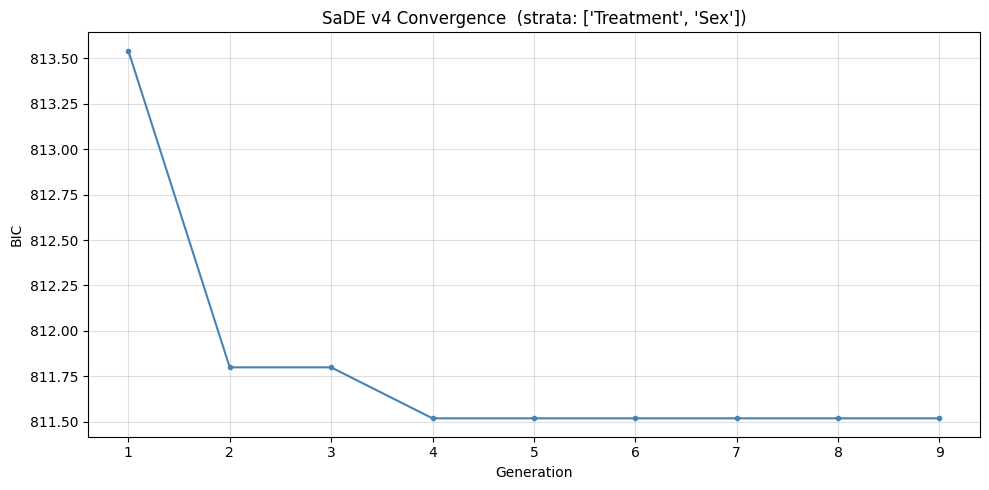


FINAL MODEL COMPARISON

Metric                    |        Traditional Cox |       FP Cox (SaDE v4)
----------------------------------------------------------------------------
Concordance index         |                 0.6454 |                 0.6454
BIC                       |                 816.32 |                 811.52
IBS (lower=better)        |                 0.1233 |                 0.1306
Log-likelihood            |              -405.5084 |              -403.1098
Parameters (k)            |                      1 |                      1
  * Both models stratified on: ['Treatment', 'Sex']


In [6]:
sd_df = pd.read_csv(
    'C:/Users/RASHMIKA/Desktop/4th/research/New folder/'
    'CSC-461-8.0-Research-Project/data/preprocess-data/preprocess_simulated_data.csv'
)

SD_COVARIATES = ['Age']
SD_STRATA     = ['Treatment', 'Sex']
SD_DURATION   = 'Time'
SD_EVENT      = 'Event'

optimizer_sd = FPCoxOptimizer(
    df=sd_df, covariates=SD_COVARIATES,
    duration_col=SD_DURATION, event_col=SD_EVENT,
    strata_cols=SD_STRATA, gamma=0.0,
)
optimizer_sd.optimize(maxiter=15, popsize=8, seed=42)

In [7]:
print('FP Cox model summary (Simulated):')
optimizer_sd.final_fp_model.print_summary()

FP Cox model summary (Simulated):


model,lifelines.CoxPHFitter
duration col,'Time'
event col,'Event'
penalizer,0.01
l1 ratio,0.0
strata,"[Treatment, Sex]"
baseline estimation,breslow
number of observations,200
number of events observed,141
partial log-likelihood,-403.11
time fit was run,2026-03-17 16:27:29 UTC


Starting SaDE v4  (gamma=1.0)
  FP covariates : ['Age']
  Strata        : ['Treatment', 'Sex']
  Pop size      : 16  |  Max gens : 15  |  Budget : 240 evals
  lp (adapt)    : every 3 gens  |  patience (stop) : 5 gens
  Objective     : BIC − 1.0·n·c-index
  Early stop at gen 9 (no improvement for 5 gens, evals used: 160)

--- Optimal Power Selection ---
  Age                   : p1=None    p2=-2
  Stratified on : ['Treatment', 'Sex']

  Best objective : 682.4383
  Generations    : 9
  Evaluations    : 160  (cache hits: 79)


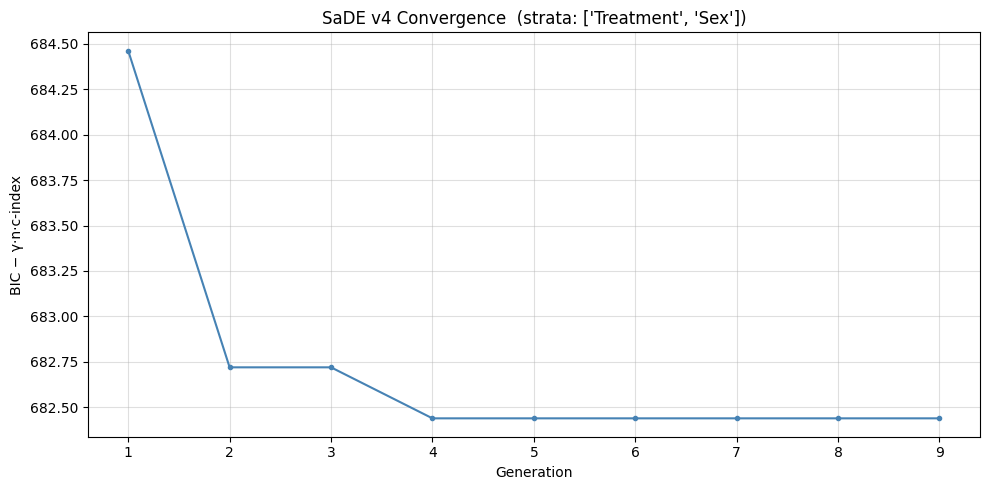


FINAL MODEL COMPARISON

Metric                    |        Traditional Cox |       FP Cox (SaDE v4)
----------------------------------------------------------------------------
Concordance index         |                 0.6454 |                 0.6454
BIC                       |                 816.32 |                 811.52
IBS (lower=better)        |                 0.1233 |                 0.1306
Log-likelihood            |              -405.5084 |              -403.1098
Parameters (k)            |                      1 |                      1
  * Both models stratified on: ['Treatment', 'Sex']


In [8]:
optimizer_sd_ci = FPCoxOptimizer(
    df=sd_df, covariates=SD_COVARIATES,
    duration_col=SD_DURATION, event_col=SD_EVENT,
    strata_cols=SD_STRATA, gamma=1.0,
)
optimizer_sd_ci.optimize(maxiter=15, popsize=8, seed=42)

---
## 5 · Dataset 2 — Haberman

Starting SaDE v4  (gamma=0.0)
  FP covariates : ['PatientAge', 'LogNodes']
  Pop size      : 32  |  Max gens : 15  |  Budget : 480 evals
  lp (adapt)    : every 3 gens  |  patience (stop) : 5 gens
  Objective     : BIC only
  Early stop at gen 5 (no improvement for 5 gens, evals used: 192)

--- Optimal Power Selection ---
  PatientAge            : p1=0.5     p2=None
  LogNodes              : p1=0.5     p2=None

  Best objective : 771.1946
  Generations    : 5
  Evaluations    : 192  (cache hits: 20)


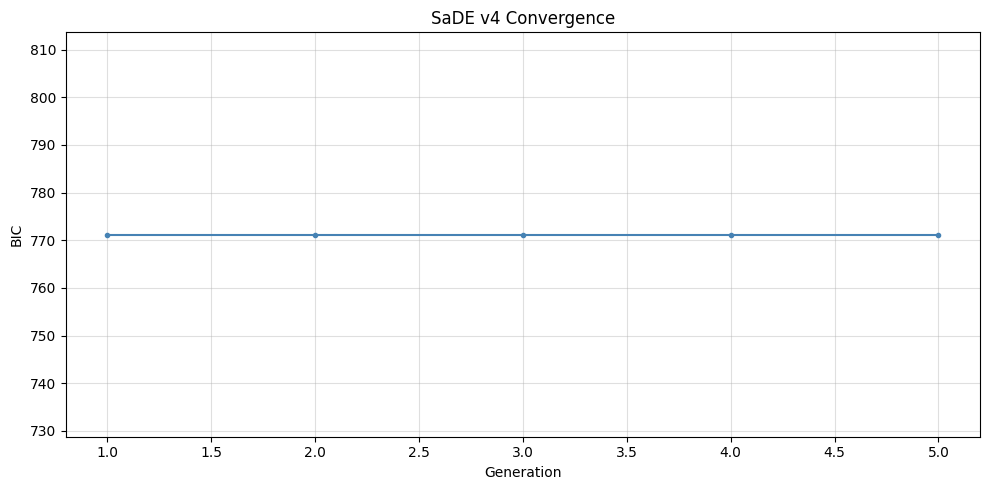


FINAL MODEL COMPARISON

Metric                    |        Traditional Cox |       FP Cox (SaDE v4)
----------------------------------------------------------------------------
Concordance index         |                 0.6682 |                 0.6710
BIC                       |                 772.23 |                 771.19
IBS (lower=better)        |                 0.1598 |                 0.1599
Log-likelihood            |              -380.3925 |              -379.8770
Parameters (k)            |                      2 |                      2


In [9]:
hm_df = pd.read_csv(
    'C:/Users/RASHMIKA/Desktop/4th/research/New folder/'
    'CSC-461-8.0-Research-Project/data/preprocess-data/preprocess_haberman.csv'
)

HM_COVARIATES = ['PatientAge', 'LogNodes']
HM_DURATION   = 'PatientYearOperation'
HM_EVENT      = 'SurvivalStatus'

optimizer_hm = FPCoxOptimizer(
    df=hm_df, covariates=HM_COVARIATES,
    duration_col=HM_DURATION, event_col=HM_EVENT, gamma=0.0,
)
optimizer_hm.optimize(maxiter=15, popsize=8, seed=42)

In [10]:
print('FP Cox model summary (Haberman):')
optimizer_hm.final_fp_model.print_summary()

FP Cox model summary (Haberman):


<lifelines.CoxPHFitter: fitted with 305 total observations, 224 right-censored observations>
             duration col = 'PatientYearOperation'
                event col = 'SurvivalStatus'
                penalizer = 0.01
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 305
number of events observed = 81
   partial log-likelihood = -379.88
         time fit was run = 2026-03-17 16:28:17 UTC

---
                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                          
PatientAge_fp_0.5  0.17      1.18      0.15           -0.13            0.47                0.87                1.60
LogNodes_fp_0.5    0.81      2.26      0.17            0.48            1.15                1.62                3.15

                   cmp to    z      p  -log2(p)
covariate                                      
PatientAge_fp_0.5    0.00 1.09   0.28      1.86
LogNodes_fp_0.5      0.00 4.78 <0.005     19.15
---
Concordance = 0.67
Partial AIC = 763.75
log-likelihood ratio test = 24.88 on 2 df
-log2(p) of ll-ratio test = 17.95

Starting SaDE v4  (gamma=1.0)
  FP covariates : ['PatientAge', 'LogNodes']
  Pop size      : 32  |  Max gens : 15  |  Budget : 480 evals
  lp (adapt)    : every 3 gens  |  patience (stop) : 5 gens
  Objective     : BIC − 1.0·n·c-index
  Early stop at gen 5 (no improvement for 5 gens, evals used: 192)

--- Optimal Power Selection ---
  PatientAge            : p1=0.5     p2=None
  LogNodes              : p1=0.5     p2=None

  Best objective : 566.5463
  Generations    : 5
  Evaluations    : 192  (cache hits: 18)


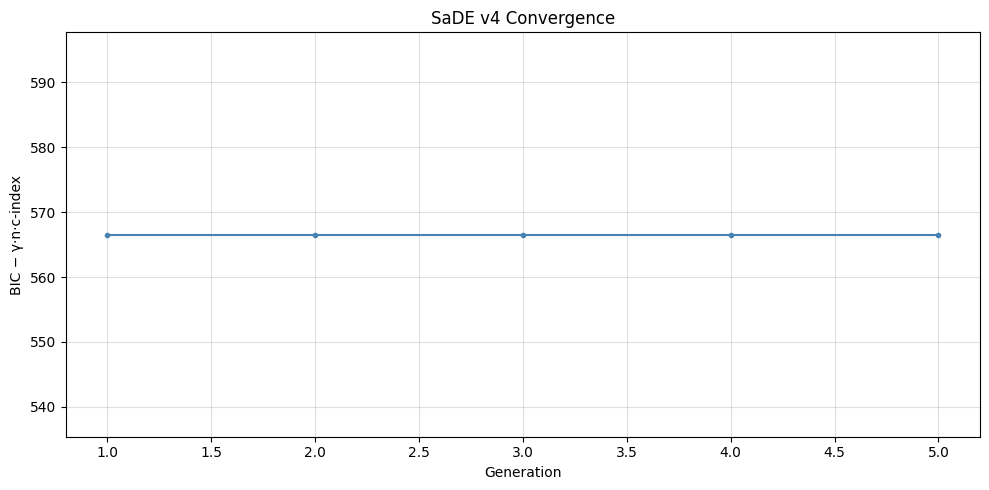


FINAL MODEL COMPARISON

Metric                    |        Traditional Cox |       FP Cox (SaDE v4)
----------------------------------------------------------------------------
Concordance index         |                 0.6682 |                 0.6710
BIC                       |                 772.23 |                 771.19
IBS (lower=better)        |                 0.1598 |                 0.1599
Log-likelihood            |              -380.3925 |              -379.8770
Parameters (k)            |                      2 |                      2


In [11]:
optimizer_hm_ci = FPCoxOptimizer(
    df=hm_df, covariates=HM_COVARIATES,
    duration_col=HM_DURATION, event_col=HM_EVENT, gamma=1.0,
)
optimizer_hm_ci.optimize(maxiter=15, popsize=8, seed=42)

---
## 6 · Dataset 3 — GBSG

**BUG 7 FIX**: `log_er` removed from `GB_COVARIATES` — it was never created
in `preprocess_gbsg.csv` (only `log_nodes` and `log_pgr` were created there).

Starting SaDE v4  (gamma=0.0)
  FP covariates : ['log_pgr', 'log_nodes', 'log_er', 'age', 'size']
  Strata        : ['meno', 'grade', 'hormon']
  Pop size      : 80  |  Max gens : 15  |  Budget : 1200 evals
  lp (adapt)    : every 3 gens  |  patience (stop) : 5 gens
  Objective     : BIC only
  Early stop at gen 5 (no improvement for 5 gens, evals used: 480)

--- Optimal Power Selection ---
  log_pgr               : p1=1       p2=None
  log_nodes             : p1=1       p2=None
  log_er                : p1=1       p2=None
  age                   : p1=1       p2=None
  size                  : p1=1       p2=None
  Stratified on : ['meno', 'grade', 'hormon']

  Best objective : 2272.6051
  Generations    : 5
  Evaluations    : 480  (cache hits: 44)


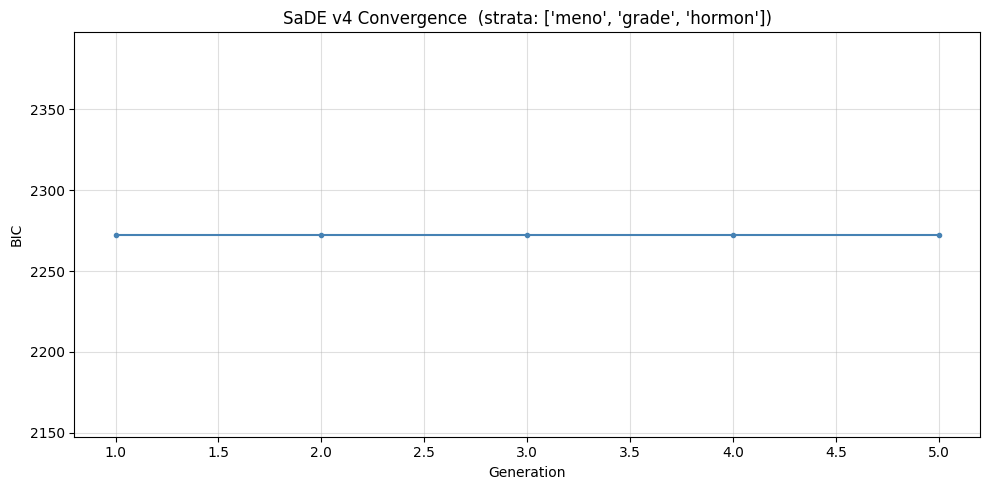


FINAL MODEL COMPARISON

Metric                    |        Traditional Cox |       FP Cox (SaDE v4)
----------------------------------------------------------------------------
Concordance index         |                 0.6673 |                 0.6673
BIC                       |                2272.61 |                2272.61
IBS (lower=better)        |                 0.2278 |                 0.2278
Log-likelihood            |             -1119.9754 |             -1119.9754
Parameters (k)            |                      5 |                      5
  * Both models stratified on: ['meno', 'grade', 'hormon']


In [12]:
gb_df = pd.read_csv(
    'C:/Users/RASHMIKA/Desktop/4th/research/New folder/'
    'CSC-461-8.0-Research-Project/data/preprocess-data/preprocess_gbsg.csv'
)

# BUG 7 FIX: log_er removed — not present in preprocess_gbsg.csv
GB_COVARIATES = ['log_pgr', 'log_nodes', 'log_er','age', 'size']
GB_STRATA     = ['meno', 'grade', 'hormon']
GB_DURATION   = 'rfstime'
GB_EVENT      = 'status'

optimizer_gb = FPCoxOptimizer(
    df=gb_df, covariates=GB_COVARIATES,
    duration_col=GB_DURATION, event_col=GB_EVENT,
    strata_cols=GB_STRATA, gamma=0.0,
)
optimizer_gb.optimize(maxiter=15, popsize=8, seed=42)

In [13]:
print('FP Cox model summary (GBSG):')
optimizer_gb.final_fp_model.print_summary()

FP Cox model summary (GBSG):


model,lifelines.CoxPHFitter
duration col,'rfstime'
event col,'status'
penalizer,0.01
l1 ratio,0.0
strata,"[meno, grade, hormon]"
baseline estimation,breslow
number of observations,686
number of events observed,299
partial log-likelihood,-1119.98
time fit was run,2026-03-17 16:33:41 UTC


Starting SaDE v4  (gamma=1.0)
  FP covariates : ['log_pgr', 'log_nodes', 'log_er', 'age', 'size']
  Strata        : ['meno', 'grade', 'hormon']
  Pop size      : 80  |  Max gens : 15  |  Budget : 1200 evals
  lp (adapt)    : every 3 gens  |  patience (stop) : 5 gens
  Objective     : BIC − 1.0·n·c-index
  Early stop at gen 14 (no improvement for 5 gens, evals used: 1200)

--- Optimal Power Selection ---
  log_pgr               : p1=None    p2=1.5
  log_nodes             : p1=2       p2=None
  log_er                : p1=None    p2=-2
  age                   : p1=0.25    p2=-3
  size                  : p1=-1      p2=-1.5
  Stratified on : ['meno', 'grade', 'hormon']

  Best objective : 1803.5889
  Generations    : 14
  Evaluations    : 1200  (cache hits: 138)


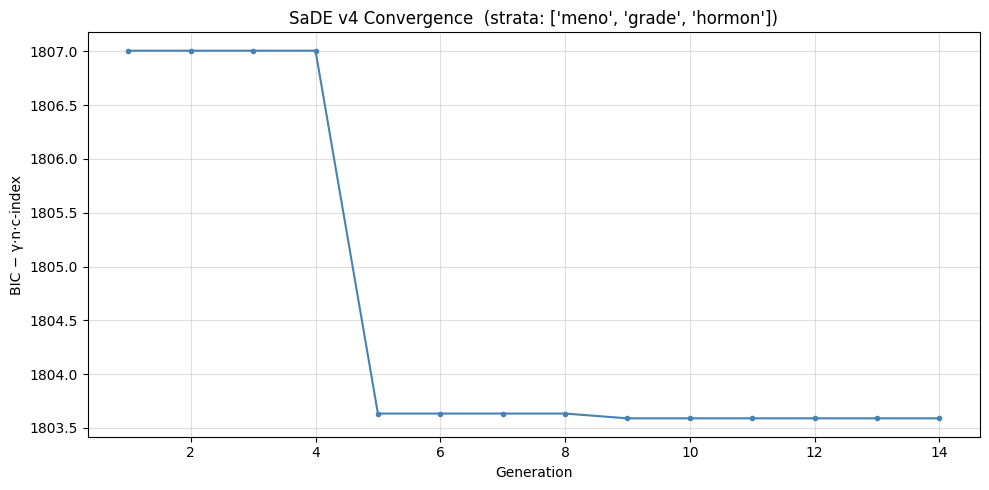


FINAL MODEL COMPARISON

Metric                    |        Traditional Cox |       FP Cox (SaDE v4)
----------------------------------------------------------------------------
Concordance index         |                 0.6673 |                 0.6826
BIC                       |                2272.61 |                2271.85
IBS (lower=better)        |                 0.2278 |                 0.2318
Log-likelihood            |             -1119.9754 |             -1113.0646
Parameters (k)            |                      5 |                      7
  * Both models stratified on: ['meno', 'grade', 'hormon']


In [14]:
optimizer_gb_ci = FPCoxOptimizer(
    df=gb_df, covariates=GB_COVARIATES,
    duration_col=GB_DURATION, event_col=GB_EVENT,
    strata_cols=GB_STRATA, gamma=1.0,
)
optimizer_gb_ci.optimize(maxiter=15, popsize=8, seed=42)

---
## 7 · Cross-dataset Summary

In [15]:
rows = [
    ('Simulated  γ=0', optimizer_sd.metrics_),
    ('Simulated  γ=1', optimizer_sd_ci.metrics_),
    ('Haberman   γ=0', optimizer_hm.metrics_),
    ('Haberman   γ=1', optimizer_hm_ci.metrics_),
    ('GBSG       γ=0', optimizer_gb.metrics_),
    ('GBSG       γ=1', optimizer_gb_ci.metrics_),
]

summary_df = pd.DataFrame({name: m for name, m in rows}).T
print('\n=== Cross-dataset Summary (v4) ===')
print(summary_df.to_string())


=== Cross-dataset Summary (v4) ===
                C-index (trad)  C-index (FP)  BIC (trad)  BIC (FP)  IBS (trad)  IBS (FP)  k (trad)  k (FP)
Simulated  γ=0          0.6454        0.6454      816.32    811.52      0.1233    0.1306       1.0     1.0
Simulated  γ=1          0.6454        0.6454      816.32    811.52      0.1233    0.1306       1.0     1.0
Haberman   γ=0          0.6682        0.6710      772.23    771.19      0.1598    0.1599       2.0     2.0
Haberman   γ=1          0.6682        0.6710      772.23    771.19      0.1598    0.1599       2.0     2.0
GBSG       γ=0          0.6673        0.6673     2272.61   2272.61      0.2278    0.2278       5.0     5.0
GBSG       γ=1          0.6673        0.6826     2272.61   2271.85      0.2278    0.2318       5.0     7.0


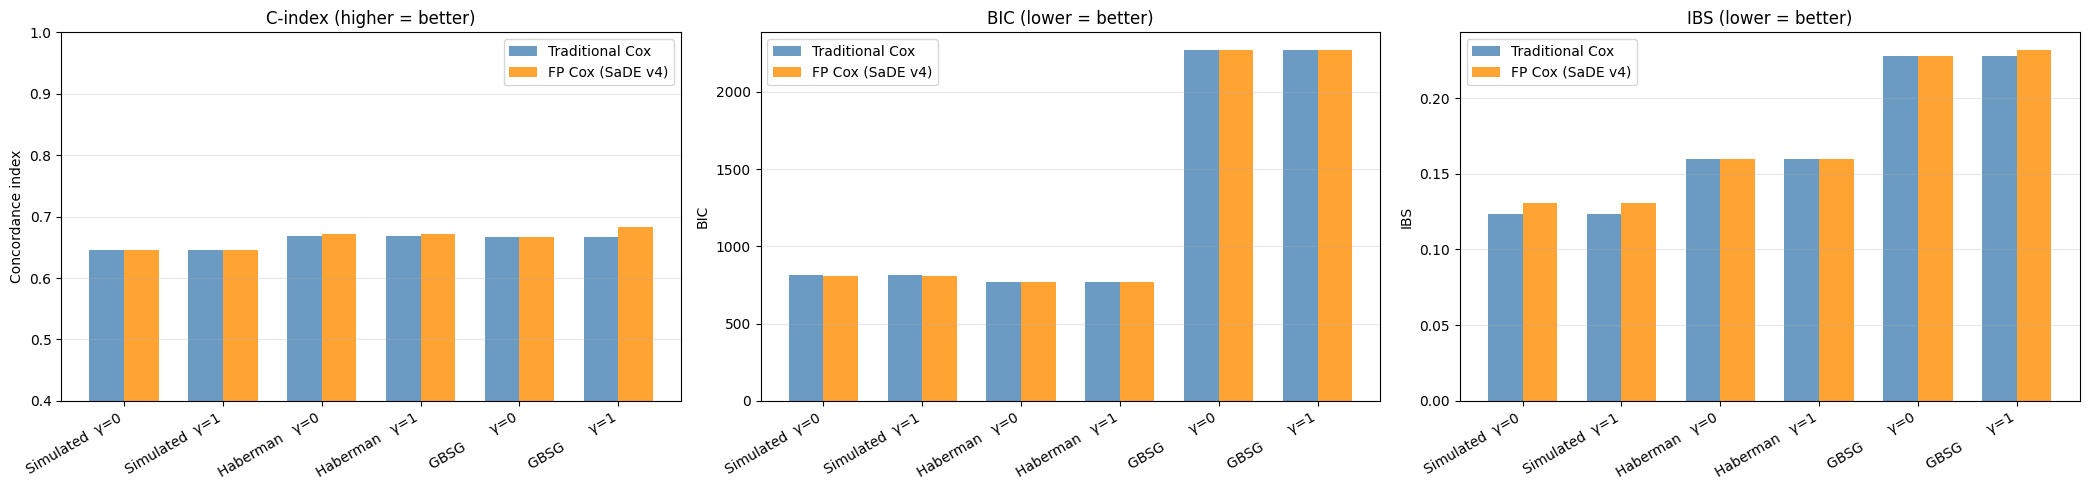

In [16]:
has_ibs = all(
    isinstance(r[1].get('IBS (FP)'), float) and
    isinstance(r[1].get('IBS (trad)'), float)
    for r in rows
)
n_plots = 3 if has_ibs else 2

fig, axes = plt.subplots(1, n_plots, figsize=(7*n_plots, 5))

labels   = [r[0] for r in rows]
c_trad   = [r[1]['C-index (trad)'] for r in rows]
c_fp     = [r[1]['C-index (FP)']   for r in rows]
bic_trad = [r[1]['BIC (trad)']     for r in rows]
bic_fp   = [r[1]['BIC (FP)']       for r in rows]

x = np.arange(len(labels));  w = 0.35

axes[0].bar(x-w/2, c_trad, w, label='Traditional Cox',  color='steelblue',  alpha=0.8)
axes[0].bar(x+w/2, c_fp,   w, label='FP Cox (SaDE v4)', color='darkorange', alpha=0.8)
axes[0].set_xticks(x); axes[0].set_xticklabels(labels, rotation=30, ha='right')
axes[0].set_ylabel('Concordance index')
axes[0].set_title('C-index (higher = better)')
axes[0].legend(); axes[0].set_ylim(0.4, 1.0); axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(x-w/2, bic_trad, w, label='Traditional Cox',  color='steelblue',  alpha=0.8)
axes[1].bar(x+w/2, bic_fp,   w, label='FP Cox (SaDE v4)', color='darkorange', alpha=0.8)
axes[1].set_xticks(x); axes[1].set_xticklabels(labels, rotation=30, ha='right')
axes[1].set_ylabel('BIC'); axes[1].set_title('BIC (lower = better)')
axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)

if has_ibs:
    ibs_trad = [r[1]['IBS (trad)'] for r in rows]
    ibs_fp   = [r[1]['IBS (FP)']   for r in rows]
    axes[2].bar(x-w/2, ibs_trad, w, label='Traditional Cox',  color='steelblue',  alpha=0.8)
    axes[2].bar(x+w/2, ibs_fp,   w, label='FP Cox (SaDE v4)', color='darkorange', alpha=0.8)
    axes[2].set_xticks(x); axes[2].set_xticklabels(labels, rotation=30, ha='right')
    axes[2].set_ylabel('IBS'); axes[2].set_title('IBS (lower = better)')
    axes[2].legend(); axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()